In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models


In [8]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

In [9]:
ann_model = models.Sequential([
    layers.Dense(units=128, activation='relu', input_shape=(784,)),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=10, activation='softmax')
])

ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
history = ann_model.fit(x_train_flat, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9224 - loss: 0.2662 - val_accuracy: 0.9592 - val_loss: 0.1368
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9652 - loss: 0.1133 - val_accuracy: 0.9661 - val_loss: 0.1115
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9766 - loss: 0.0770 - val_accuracy: 0.9663 - val_loss: 0.1126
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9820 - loss: 0.0584 - val_accuracy: 0.9710 - val_loss: 0.0976
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9855 - loss: 0.0455 - val_accuracy: 0.9727 - val_loss: 0.0968
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9888 - loss: 0.0349 - val_accuracy: 0.9743 - val_loss: 0.0907
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9737 - val_loss: 0.0978
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9923 - loss: 0.0240

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9760 - loss: 0.0981
0.9760000109672546


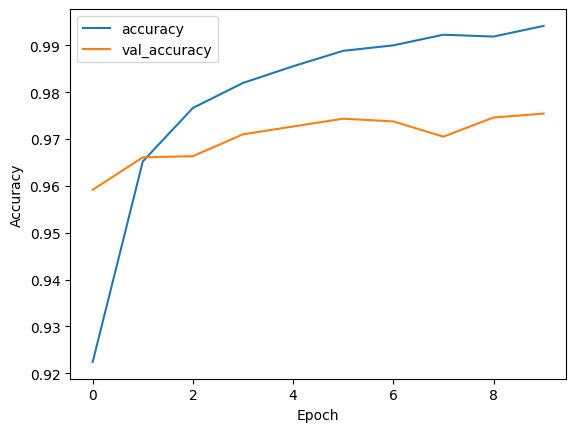

In [11]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

test_loss, test_acc = ann_model.evaluate(x_test_flat, y_test)
print(test_acc)